# Importações

In [2]:
import pandas as pd
import requests

# Testes iniciais (conhecendo a API)

In [3]:
# Localização (São Paulo) - Teste inicial
latitude = -23.5505
longitude = -46.6333

# Intervalo de datas
start_date = "20240101"
end_date = "20241231"

# Variáveis climáticas
parameters = [
    "PRECTOTCORR",        # Precipitação
    "T2M",                # Temperatura média
    "RH2M",               # Umidade relativa
    "WS2M",               # Velocidade do vento
    "ALLSKY_SFC_SW_DWN"   # Radiação solar
]

parameters_str = ",".join(parameters)

In [4]:
url = (
    "https://power.larc.nasa.gov/api/temporal/daily/point"
    f"?parameters={parameters_str}"
    "&community=AG"
    f"&longitude={longitude}"
    f"&latitude={latitude}"
    f"&start={start_date}"
    f"&end={end_date}"
    "&format=JSON"
)

print("URL utilizada:")
print(url)

response = requests.get(url)

print("\nStatus da requisição:")
print(response.status_code)

URL utilizada:
https://power.larc.nasa.gov/api/temporal/daily/point?parameters=PRECTOTCORR,T2M,RH2M,WS2M,ALLSKY_SFC_SW_DWN&community=AG&longitude=-46.6333&latitude=-23.5505&start=20240101&end=20241231&format=JSON

Status da requisição:
200


In [5]:
# Transformando em Dataframe para consulta

data = response.json()

parameters_data = data["properties"]["parameter"]

df = pd.DataFrame(parameters_data)

df.index = pd.to_datetime(df.index)

df = df.reset_index()

df.rename(columns={"index": "date"}, inplace=True)

df.head()

,date,PRECTOTCORR,T2M,RH2M,WS2M,ALLSKY_SFC_SW_DWN
0,2024-01-01,0.06,23.15,69.16,2.99,16.71
1,2024-01-02,0.37,23.99,69.60,2.16,20.61
2,2024-01-03,4.72,24.20,75.18,2.47,16.73
3,2024-01-04,4.64,23.63,77.13,3.15,16.95
4,2024-01-05,2.36,23.16,75.31,2.68,21.71


In [6]:
# Validando os valores
print("Informações gerais:")
display(df.info())

print("\nValores nulos:")
display(df.isnull().sum())

print("\nEstatísticas:")
display(df.describe())

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               366 non-null    datetime64[ns]
 1   PRECTOTCORR        366 non-null    float64       
 2   T2M                366 non-null    float64       
 3   RH2M               366 non-null    float64       
 4   WS2M               366 non-null    float64       
 5   ALLSKY_SFC_SW_DWN  366 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 17.3 KB


None


Valores nulos:


,0
date,0
PRECTOTCORR,0
T2M,0
RH2M,0
WS2M,0
ALLSKY_SFC_SW_DWN,0



Estatísticas:


,date,PRECTOTCORR,T2M,RH2M,WS2M,ALLSKY_SFC_SW_DWN
count,366,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2024-07-01 12:00:00.000000256,2.736120,21.516639,71.147131,2.298306,16.328251
min,2024-01-01 00:00:00,0.000000,10.230000,28.640000,0.830000,1.670000
25%,2024-04-01 06:00:00,0.030000,19.422500,63.820000,1.610000,12.962500
50%,2024-07-01 12:00:00,0.275000,22.190000,73.950000,2.140000,16.625000
75%,2024-09-30 18:00:00,3.067500,23.812500,81.057500,2.800000,20.305000
max,2024-12-31 00:00:00,39.170000,28.050000,93.140000,4.990000,29.240000
std,NaN,5.395045,3.259038,12.620045,0.840585,5.485059


In [7]:
df.to_csv(
    "nasa_power_sao_paulo_2024.csv",
    index=False
)

# Código para um protótipo inicial da ideia

In [8]:
#   Como fiz o teste para conhecer a API e só considerar SP, agora é acrescentar
# mais cidades do estado do Brasil para se aproximar de um protótipo da ideia final.
# Considerando 6 capitais agora

cities = {
    "Sao_Paulo": (-23.5505, -46.6333),
    "Rio_de_Janeiro": (-22.9068, -43.1729),
    "Curitiba": (-25.4284, -49.2733),
    "Florianopolis": (-27.5949, -48.5482),
    "Porto_Alegre": (-30.0346, -51.2177),
    "Belo_Horizonte": (-19.9167, -43.9345)
}

In [11]:
start_date = "20240101"
end_date = "20241231"

parameters = [
    "PRECTOTCORR",
    "T2M",
    "RH2M",
    "WS2M",
    "ALLSKY_SFC_SW_DWN"
]

parameters_str = ",".join(parameters)

In [12]:
def get_nasa_data(city, latitude, longitude):

    url = (
        "https://power.larc.nasa.gov/api/temporal/daily/point"
        f"?parameters={parameters_str}"
        "&community=AG"
        f"&longitude={longitude}"
        f"&latitude={latitude}"
        f"&start={start_date}"
        f"&end={end_date}"
        "&format=JSON"
    )

    response = requests.get(url)

    if response.status_code != 200:
        print(f"Erro ao consultar {city}")
        return None

    data = response.json()

    parameters_data = data["properties"]["parameter"]

    df = pd.DataFrame(parameters_data)

    df.index = pd.to_datetime(df.index)

    df = df.reset_index()

    df.rename(columns={"index": "date"}, inplace=True)

    df["city"] = city
    df["latitude"] = latitude
    df["longitude"] = longitude

    return df

In [13]:
all_dataframes = []

for city, coordinates in cities.items():

    latitude = coordinates[0]
    longitude = coordinates[1]

    print(f"Baixando dados de {city}...")

    city_df = get_nasa_data(
        city,
        latitude,
        longitude
    )

    if city_df is not None:
        all_dataframes.append(city_df)

Baixando dados de Sao_Paulo...
Baixando dados de Rio_de_Janeiro...
Baixando dados de Curitiba...
Baixando dados de Florianopolis...
Baixando dados de Porto_Alegre...
Baixando dados de Belo_Horizonte...


In [14]:
df = pd.concat(
    all_dataframes,
    ignore_index=True
)

In [15]:
print("Quantidade de linhas:")
print(len(df))

print("\nQuantidade de colunas:")
print(len(df.columns))

df.head()

Quantidade de linhas:
2196

Quantidade de colunas:
9


,date,PRECTOTCORR,T2M,RH2M,WS2M,ALLSKY_SFC_SW_DWN,city,latitude,longitude
0,2024-01-01,0.06,23.15,69.16,2.99,16.71,Sao_Paulo,-23.5505,-46.6333
1,2024-01-02,0.37,23.99,69.60,2.16,20.61,Sao_Paulo,-23.5505,-46.6333
2,2024-01-03,4.72,24.20,75.18,2.47,16.73,Sao_Paulo,-23.5505,-46.6333
3,2024-01-04,4.64,23.63,77.13,3.15,16.95,Sao_Paulo,-23.5505,-46.6333
4,2024-01-05,2.36,23.16,75.31,2.68,21.71,Sao_Paulo,-23.5505,-46.6333


## Validação dos dados

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2196 entries, 0 to 2195
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               2196 non-null   datetime64[ns]
 1   PRECTOTCORR        2196 non-null   float64       
 2   T2M                2196 non-null   float64       
 3   RH2M               2196 non-null   float64       
 4   WS2M               2196 non-null   float64       
 5   ALLSKY_SFC_SW_DWN  2196 non-null   float64       
 6   city               2196 non-null   object        
 7   latitude           2196 non-null   float64       
 8   longitude          2196 non-null   float64       
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 154.5+ KB


In [19]:
df.isnull().sum()

,0
date,0
PRECTOTCORR,0
T2M,0
RH2M,0
WS2M,0
ALLSKY_SFC_SW_DWN,0
city,0
latitude,0
longitude,0


In [20]:
df.describe()

,date,PRECTOTCORR,T2M,RH2M,WS2M,ALLSKY_SFC_SW_DWN,latitude,longitude
count,2196,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000,2196.000000
mean,2024-07-01 12:00:00,3.512805,21.359212,76.627992,2.281940,16.089731,-24.905317,-47.129983
min,2024-01-01 00:00:00,0.000000,5.270000,23.860000,0.370000,0.710000,-30.034600,-51.217700
25%,2024-04-01 00:00:00,0.040000,19.470000,71.377500,1.480000,11.842500,-27.594900,-49.273300
50%,2024-07-01 12:00:00,0.425000,22.050000,79.415000,2.140000,16.310000,-24.489450,-47.590750
75%,2024-10-01 00:00:00,3.612500,24.000000,84.730000,2.922500,20.680000,-22.906800,-43.934500
max,2024-12-31 00:00:00,85.450000,29.270000,97.150000,7.220000,32.930000,-19.916700,-43.172900
std,NaN,7.468653,3.867850,11.765930,1.098421,6.478409,3.280303,2.870929


## Salvando o CSV: dados brutos

In [21]:
df.to_csv(
    "sentinel_sos_raw.csv",
    index=False
)

print("CSV salvo com sucesso!")

CSV salvo com sucesso!


## Engenharia de atributos


### Estação do ano

In [22]:
df["month"] = df["date"].dt.month

df["year"] = df["date"].dt.year

df["day"] = df["date"].dt.day

In [23]:
def get_season(month):

    if month in [12, 1, 2]:
        return "Summer"

    elif month in [3, 4, 5]:
        return "Autumn"

    elif month in [6, 7, 8]:
        return "Winter"

    else:
        return "Spring"

In [24]:
df["season"] = df["month"].apply(get_season)

### Índice de chuva

In [25]:
df["rain_intensity"] = (
    df["PRECTOTCORR"] *
    df["RH2M"]
)

### Índice de tempestade

In [26]:
df["storm_index"] = (
    df["PRECTOTCORR"] *
    df["WS2M"]
)

### Índice de calor

In [27]:
df["heat_index"] = (
    df["T2M"] *
    (df["RH2M"] / 100)
)

### Chuva extrema

In [28]:
df["extreme_rain"] = (
    df["PRECTOTCORR"] > 40
).astype(int)

### Criar variável alvo (risk_level)

In [29]:
def classify_risk(row):

    if row["PRECTOTCORR"] >= 50:
        return 2

    elif row["PRECTOTCORR"] >= 20:
        return 1

    return 0

In [30]:
df["risk_level"] = df.apply(
    classify_risk,
    axis=1
)

In [31]:
# Resultado df final
df.head()

,date,PRECTOTCORR,T2M,RH2M,WS2M,ALLSKY_SFC_SW_DWN,city,latitude,longitude,month,year,day,season,rain_intensity,storm_index,heat_index,extreme_rain,risk_level
0,2024-01-01,0.06,23.15,69.16,2.99,16.71,Sao_Paulo,-23.5505,-46.6333,1,2024,1,Summer,4.1496,0.1794,16.010540,0,0
1,2024-01-02,0.37,23.99,69.60,2.16,20.61,Sao_Paulo,-23.5505,-46.6333,1,2024,2,Summer,25.7520,0.7992,16.697040,0,0
2,2024-01-03,4.72,24.20,75.18,2.47,16.73,Sao_Paulo,-23.5505,-46.6333,1,2024,3,Summer,354.8496,11.6584,18.193560,0,0
3,2024-01-04,4.64,23.63,77.13,3.15,16.95,Sao_Paulo,-23.5505,-46.6333,1,2024,4,Summer,357.8832,14.6160,18.225819,0,0
4,2024-01-05,2.36,23.16,75.31,2.68,21.71,Sao_Paulo,-23.5505,-46.6333,1,2024,5,Summer,177.7316,6.3248,17.441796,0,0


### Salvando dataset final

In [32]:
df.to_csv(
    "sentinel_sos_features.csv",
    index=False
)

print("Dataset final salvo!")

Dataset final salvo!


## Preparando os dados

In [33]:
features = [
    "PRECTOTCORR",
    "T2M",
    "RH2M",
    "WS2M",
    "ALLSKY_SFC_SW_DWN",
    "month",
    "rain_intensity",
    "storm_index",
    "heat_index",
    "extreme_rain"
]

In [34]:
target = "risk_level"

In [35]:
X = df[features]

y = df[target]

## Treino e teste

In [36]:
# Importação
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
print(X_train.shape)
print(X_test.shape)

(1756, 10)
(440, 10)


## Random Forest

In [39]:
# Importação
from sklearn.ensemble import RandomForestClassifier

In [40]:
# Treinando o modelo
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [43]:
# Previsões
rf_predictions = rf_model.predict(
    X_test
)

## XGBoost

In [44]:
# Instalação (estou usando o Colab por isso)
!pip install xgboost

In [45]:
# Importação
from xgboost import XGBClassifier

In [46]:
# Treinando modelo
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [47]:
xgb_predictions = xgb_model.predict(
    X_test
)

## Métricas

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [50]:
# Funçãozinha para organização
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    print(f"\n{model_name}")
    print("-"*30)
    print("Accuracy:", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall:", round(recall,4))
    print("F1:", round(f1,4))

In [51]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_predictions
)


Random Forest
------------------------------
Accuracy: 0.9977
Precision: 0.9977
Recall: 0.9977
F1: 0.9977

XGBoost
------------------------------
Accuracy: 0.9977
Precision: 0.9977
Recall: 0.9977
F1: 0.9977


## Matriz de confusão

In [52]:
# Importação
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

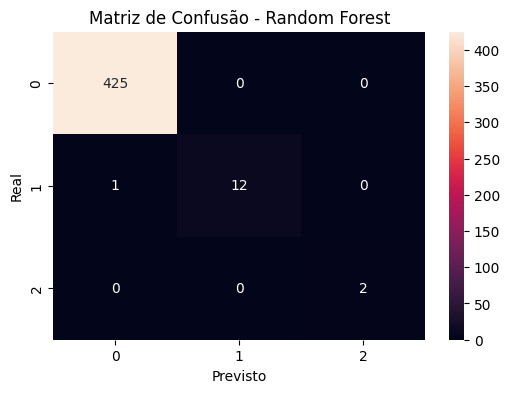

In [53]:
cm_rf = confusion_matrix(
    y_test,
    rf_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

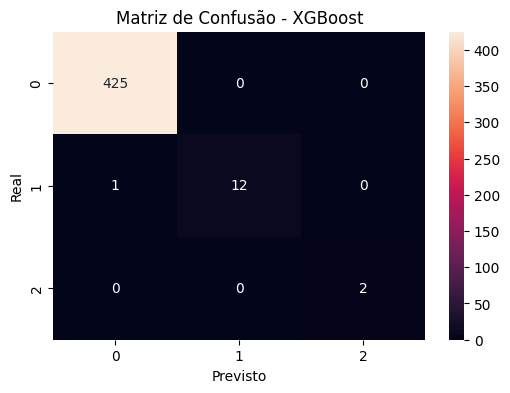

In [54]:
cm_xgb = confusion_matrix(
    y_test,
    xgb_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d"
)

plt.title("Matriz de Confusão - XGBoost")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

## SHAP

In [55]:
# Instalação
!pip install shap

In [56]:
import shap

### Explicador Random Forest

In [57]:
explainer = shap.TreeExplainer(
    rf_model
)

In [58]:
shap_values = explainer.shap_values(
    X_test
)

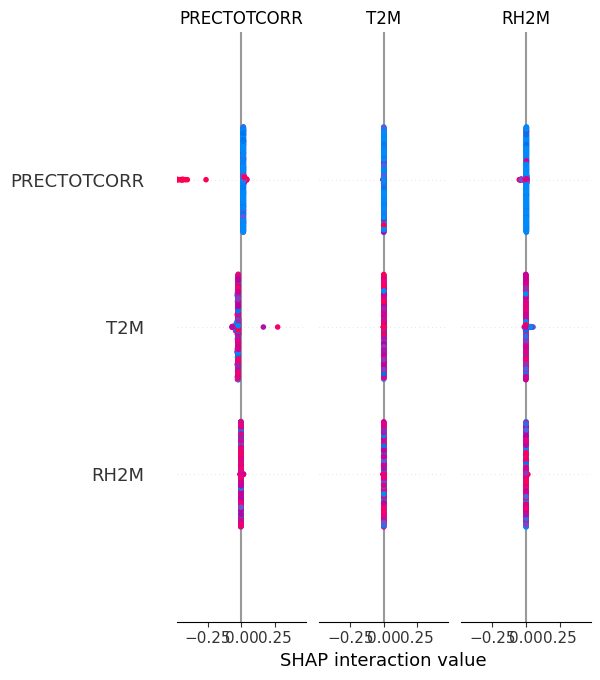

In [59]:
shap.summary_plot(
    shap_values,
    X_test
)

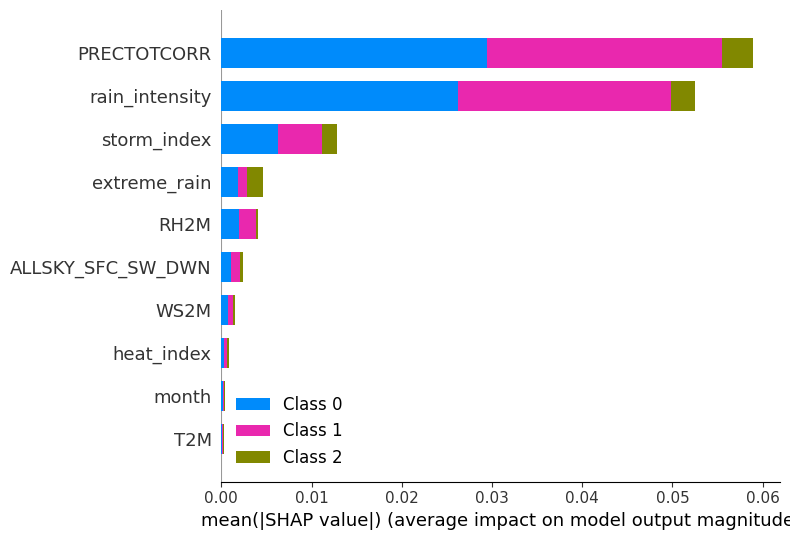

In [60]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

# **📄 Relatório — Interpretabilidade do Modelo com SHAP (Random Forest)**

Com o objetivo de compreender como o modelo Random Forest toma decisões na classificação de risco climático, foi utilizada a biblioteca SHAP (SHapley Additive exPlanations).

O SHAP permite identificar o impacto de cada variável no resultado das previsões realizadas pelo modelo de Machine Learning, tornando o processo mais transparente e interpretável.

## Análise das Variáveis Mais Importantes

Os resultados obtidos demonstraram que as variáveis mais relevantes para a previsão do nível de risco foram:

1. PRECTOTCORR (Precipitação)

A variável PRECTOTCORR apresentou o maior impacto médio no modelo, indicando que a quantidade de chuva é o principal fator utilizado pelo Random Forest para identificar situações de risco climático.

Isso está diretamente relacionado à ocorrência de:

* enchentes;
* alagamentos;
* tempestades severas;
* deslizamentos.

2. rain_intensity

A feature rain_intensity, criada durante a etapa de engenharia de atributos, também apresentou elevada relevância.

Essa variável combina precipitação e umidade relativa, permitindo ao modelo identificar cenários de maior intensidade climática.

O resultado demonstra que a engenharia de atributos contribuiu significativamente para melhorar a capacidade preditiva do modelo.

3. storm_index

A variável storm_index, baseada na combinação entre precipitação e velocidade do vento, apresentou importância moderada no modelo.

Isso evidencia que condições climáticas severas associadas a chuva e vento influenciam diretamente na classificação de risco.

4. extreme_rain

A feature extreme_rain também contribuiu para o modelo ao identificar eventos de chuva extrema.

Seu impacto foi menor em comparação às variáveis principais, porém ainda relevante para a classificação de cenários críticos.

## Variáveis com Menor Influência

As variáveis:

* temperatura média (T2M);
* mês;
* índice de calor (heat_index);

apresentaram menor impacto nas decisões do modelo.

Isso indica que, para o contexto analisado, os eventos de risco climático estão mais associados à precipitação do que às variações térmicas.

## Conclusão

Os resultados do SHAP demonstraram que o modelo Random Forest conseguiu aprender padrões coerentes com eventos climáticos reais.

Além disso, a análise confirmou que as variáveis derivadas criadas na etapa de engenharia de atributos tiveram contribuição importante para o desempenho do modelo.

Dessa forma, o uso do SHAP permitiu aumentar a transparência e interpretabilidade da solução Sentinel SOS, tornando possível compreender como o sistema realiza previsões de risco climático com base em dados orbitais da NASA POWER API.

### Explicador XGBoost

In [61]:
 # Instalação
 !pip install shap xgboost

In [62]:
import shap
import xgboost as xgb

In [63]:
explainer_xgb = shap.TreeExplainer(
    xgb_model
)

In [64]:
shap_values_xgb = explainer_xgb.shap_values(
    X_test
)

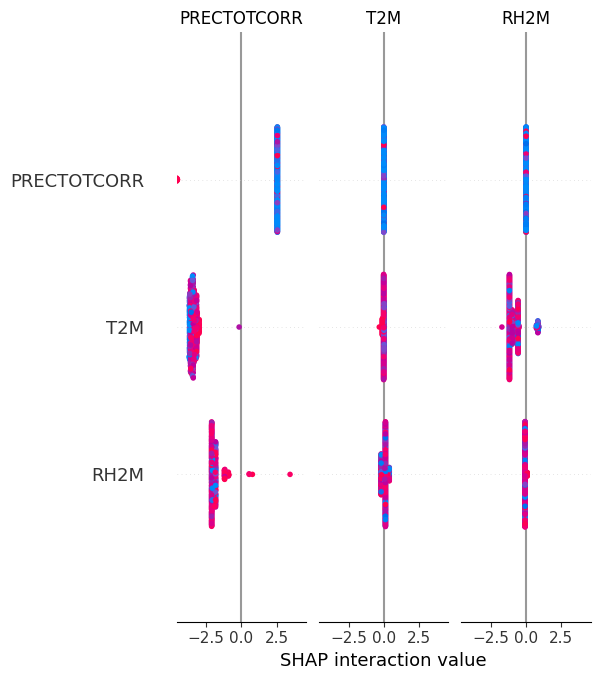

In [65]:
shap.summary_plot(
    shap_values_xgb,
    X_test
)

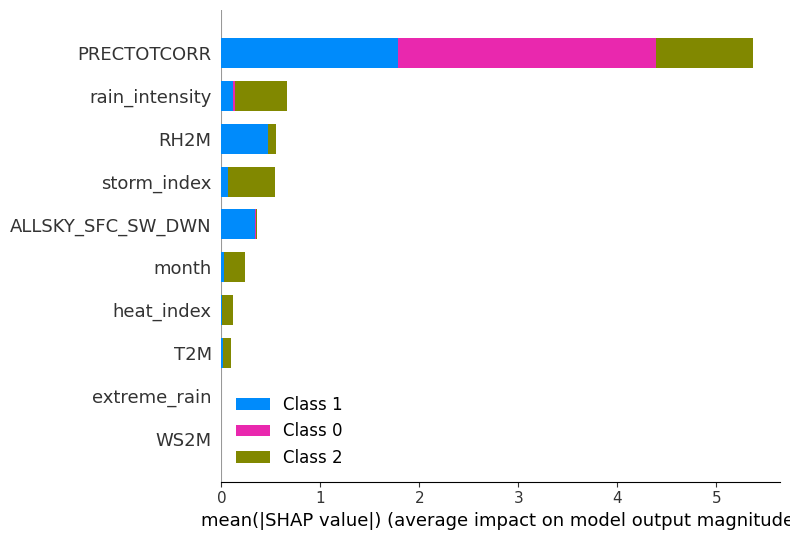

In [66]:
shap.summary_plot(
    shap_values_xgb,
    X_test,
    plot_type="bar"
)

# **📄 Relatório — Interpretabilidade do Modelo com SHAP (XGBoost)**

Após o treinamento do modelo XGBoost para classificação de risco climático no projeto Sentinel SOS, foi aplicada a técnica SHAP (SHapley Additive exPlanations) para interpretar as decisões do modelo e identificar quais variáveis tiveram maior influência nas previsões.

O objetivo dessa etapa foi aumentar a transparência do sistema de Inteligência Artificial, permitindo compreender como os fatores climáticos impactam diretamente a classificação do nível de risco.

## Análise das Variáveis Mais Importantes

A análise dos gráficos SHAP demonstrou que o modelo XGBoost apresentou forte dependência das variáveis relacionadas à precipitação, mantendo coerência com o contexto de eventos climáticos extremos.

1. PRECTOTCORR (Precipitação)

A variável PRECTOTCORR foi a mais relevante no modelo XGBoost, apresentando o maior impacto médio absoluto nos valores SHAP.

O resultado indica que a quantidade de chuva foi o principal fator utilizado pelo modelo para prever cenários de risco climático.

Essa relação é esperada, considerando que eventos como:

* enchentes;
* alagamentos;
* deslizamentos;
* tempestades severas;

estão diretamente associados ao aumento da precipitação.

Além disso, observou-se que o XGBoost atribuiu pesos ainda maiores à precipitação em comparação ao Random Forest, indicando maior sensibilidade do modelo às variações de chuva.

2. rain_intensity

A variável rain_intensity apresentou a segunda maior relevância no modelo.

Essa feature foi criada durante a etapa de engenharia de atributos através da combinação entre:

* precipitação;
* umidade relativa.

Os resultados demonstram que o XGBoost conseguiu capturar relações não lineares entre essas variáveis, aumentando sua capacidade preditiva.

A importância dessa feature evidencia que a engenharia de atributos contribuiu significativamente para melhorar o desempenho do modelo.

3. RH2M (Umidade Relativa)

A umidade relativa apresentou influência moderada nas previsões do modelo.

O gráfico SHAP demonstrou que níveis elevados de umidade aumentam a contribuição para classes de maior risco, especialmente quando combinados com altos índices de precipitação.

4. storm_index

A variável storm_index também apresentou relevância importante no processo de decisão.

Essa feature combina:

* precipitação;
* velocidade do vento.

Seu impacto demonstra que o modelo considera cenários climáticos mais severos como fatores relevantes para classificação de risco.

## Variáveis Secundárias

Outras variáveis, como:

* ALLSKY_SFC_SW_DWN;
* month;
* heat_index;

apresentaram menor impacto individual no modelo.

Já as variáveis:

* T2M;
* WS2M;
* extreme_rain;

demonstraram influência reduzida nas previsões finais.

## Análise do Gráfico de Interações SHAP

O gráfico de interações SHAP demonstrou que:

PRECTOTCORR possui forte influência independente;
RH2M apresenta maior impacto quando associada à precipitação;
T2M possui comportamento mais distribuído e menos determinante.

Os padrões observados indicam que o modelo XGBoost consegue capturar relações complexas entre variáveis climáticas, especialmente entre chuva e umidade.

## Conclusão

Os resultados obtidos com SHAP demonstraram que o modelo XGBoost conseguiu identificar padrões climáticos coerentes com situações reais de risco ambiental.

A precipitação foi o principal fator responsável pelas previsões, seguida pelas variáveis derivadas criadas durante a engenharia de atributos.

Além disso, a análise confirmou que o XGBoost possui alta capacidade de capturar relações não lineares e interações entre variáveis climáticas, tornando o modelo altamente eficiente para o contexto do projeto Sentinel SOS.

# Comparação — Random Forest vs XGBoost (SHAP)

## Comparação de Interpretabilidade entre os Modelos

A análise comparativa utilizando SHAP permitiu identificar diferenças importantes entre os modelos Random Forest e XGBoost.

Ambos os modelos apresentaram comportamento coerente ao apontar a precipitação (`PRECTOTCORR`) como principal variável responsável pela classificação de risco climático.

Entretanto, foram observadas diferenças relevantes na forma como cada algoritmo interpreta os dados.

---

# Random Forest

O Random Forest apresentou comportamento mais equilibrado entre as variáveis.

### Características observadas:

- distribuição mais uniforme da importância das features;
- maior estabilidade entre variáveis secundárias;
- menor sensibilidade a pequenas variações climáticas;
- interpretação mais conservadora.

O modelo destacou principalmente:

1. `PRECTOTCORR`
2. `rain_intensity`
3. `storm_index`

A importância das features derivadas mostrou que a engenharia de atributos teve impacto positivo no desempenho do algoritmo.

---

# XGBoost

O XGBoost apresentou comportamento mais agressivo e sensível às variáveis principais.

### Características observadas:

- forte concentração de importância em `PRECTOTCORR`;
- maior capacidade de capturar relações não lineares;
- maior sensibilidade às interações entre chuva e umidade;
- separação mais evidente entre classes.

Além disso, o modelo demonstrou melhor aproveitamento das features derivadas criadas no projeto.

---

# Diferenças Observadas

| Aspecto | Random Forest | XGBoost |
|---|---|---|
| Sensibilidade à precipitação | Alta | Muito alta |
| Distribuição das importâncias | Mais equilibrada | Mais concentrada |
| Relações não lineares | Boa | Excelente |
| Interações entre variáveis | Moderadas | Fortes |
| Complexidade do modelo | Média | Alta |
| Interpretabilidade | Mais simples | Mais detalhada |

---

# Conclusão Comparativa

A análise SHAP demonstrou que ambos os modelos foram eficientes na identificação de padrões climáticos relacionados a eventos extremos.

O Random Forest apresentou maior estabilidade e simplicidade interpretativa, enquanto o XGBoost demonstrou maior capacidade preditiva e melhor captura de interações complexas entre variáveis.

Considerando os resultados obtidos, o modelo XGBoost mostrou-se mais adequado para o projeto Sentinel SOS devido à sua maior sensibilidade aos fatores críticos de risco climático e melhor aproveitamento das features derivadas criadas durante o pipeline de Machine Learning.